In [4]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Notebook Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
# Load Dataset
df = pd.read_csv(r"D:\PERSONAL\PROJECTS\Internship\Web-Traffic-Analytics\data\raw\website_wata.csv")

# Display first five rows
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
0,5,11.051381,0.230652,Organic,3.890460,3,1.0
1,4,3.429316,0.391001,Social,8.478174,0,1.0
2,4,1.621052,0.397986,Organic,9.636170,2,1.0
3,5,3.629279,0.180458,Organic,2.071925,3,1.0
4,5,4.235843,0.291541,Paid,1.960654,5,1.0


In [6]:
# Shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 2000
Columns: 7


In [7]:
# Column Names
df.columns.tolist()

['Page Views',
 'Session Duration',
 'Bounce Rate',
 'Traffic Source',
 'Time on Page',
 'Previous Visits',
 'Conversion Rate']

In [8]:
# Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Page Views        2000 non-null   int64  
 1   Session Duration  2000 non-null   float64
 2   Bounce Rate       2000 non-null   float64
 3   Traffic Source    2000 non-null   object 
 4   Time on Page      2000 non-null   float64
 5   Previous Visits   2000 non-null   int64  
 6   Conversion Rate   2000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 109.5+ KB


In [9]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Page Views,2000.0,4.950500,2.183903,0.000000,3.000000,5.000000,6.000000,14.000000
Session Duration,2000.0,3.022045,3.104518,0.003613,0.815828,1.993983,4.197569,20.290516
Bounce Rate,2000.0,0.284767,0.159781,0.007868,0.161986,0.266375,0.388551,0.844939
Time on Page,2000.0,4.027439,2.887422,0.068515,1.935037,3.315316,5.414627,24.796182
Previous Visits,2000.0,1.978500,1.432852,0.000000,1.000000,2.000000,3.000000,9.000000
Conversion Rate,2000.0,0.982065,0.065680,0.343665,1.000000,1.000000,1.000000,1.000000


In [10]:
# First Five Rows
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
0,5,11.051381,0.230652,Organic,3.890460,3,1.0
1,4,3.429316,0.391001,Social,8.478174,0,1.0
2,4,1.621052,0.397986,Organic,9.636170,2,1.0
3,5,3.629279,0.180458,Organic,2.071925,3,1.0
4,5,4.235843,0.291541,Paid,1.960654,5,1.0


In [11]:
# Last Five Rows
df.tail()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
1995,1,2.724513,0.207187,Referral,1.324206,2,1.0
1996,3,0.392856,0.095559,Organic,3.824416,1,1.0
1997,4,9.899823,0.446622,Organic,1.288675,1,1.0
1998,3,0.393319,0.278340,Paid,5.037584,2,1.0
1999,3,0.882638,0.338026,Direct,5.186908,3,1.0


In [12]:
# Missing values
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': (missing_values/len(df))*100
})

missing_df

,Missing Values,Percentage
Page Views,0,0.0
Session Duration,0,0.0
Bounce Rate,0,0.0
Traffic Source,0,0.0
Time on Page,0,0.0
Previous Visits,0,0.0
Conversion Rate,0,0.0


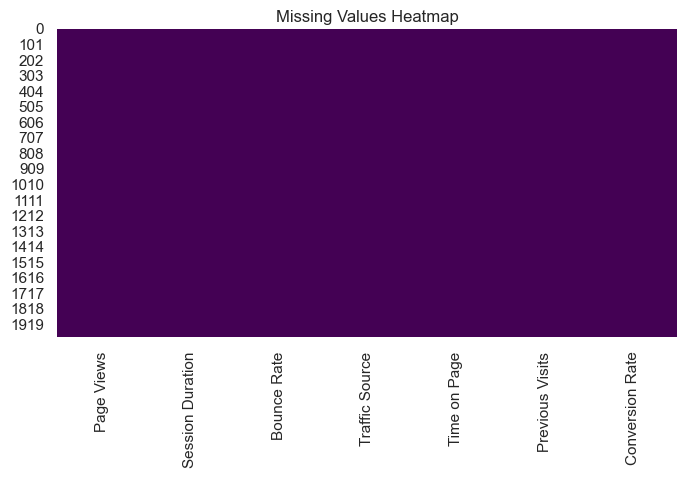

In [13]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values Heatmap")
plt.show()

In [14]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [15]:
df.dtypes

Page Views            int64
Session Duration    float64
Bounce Rate         float64
Traffic Source       object
Time on Page        float64
Previous Visits       int64
Conversion Rate     float64
dtype: object

In [16]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].nunique())


Page Views
15

Session Duration
2000

Bounce Rate
2000

Traffic Source
5

Time on Page
2000

Previous Visits
10

Conversion Rate
228


In [17]:
df['Traffic Source'].value_counts()

Traffic Source
Organic     786
Paid        428
Referral    301
Social      269
Direct      216
Name: count, dtype: int64

In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

Index(['Page Views', 'Session Duration', 'Bounce Rate', 'Time on Page',
       'Previous Visits', 'Conversion Rate'],
      dtype='object')

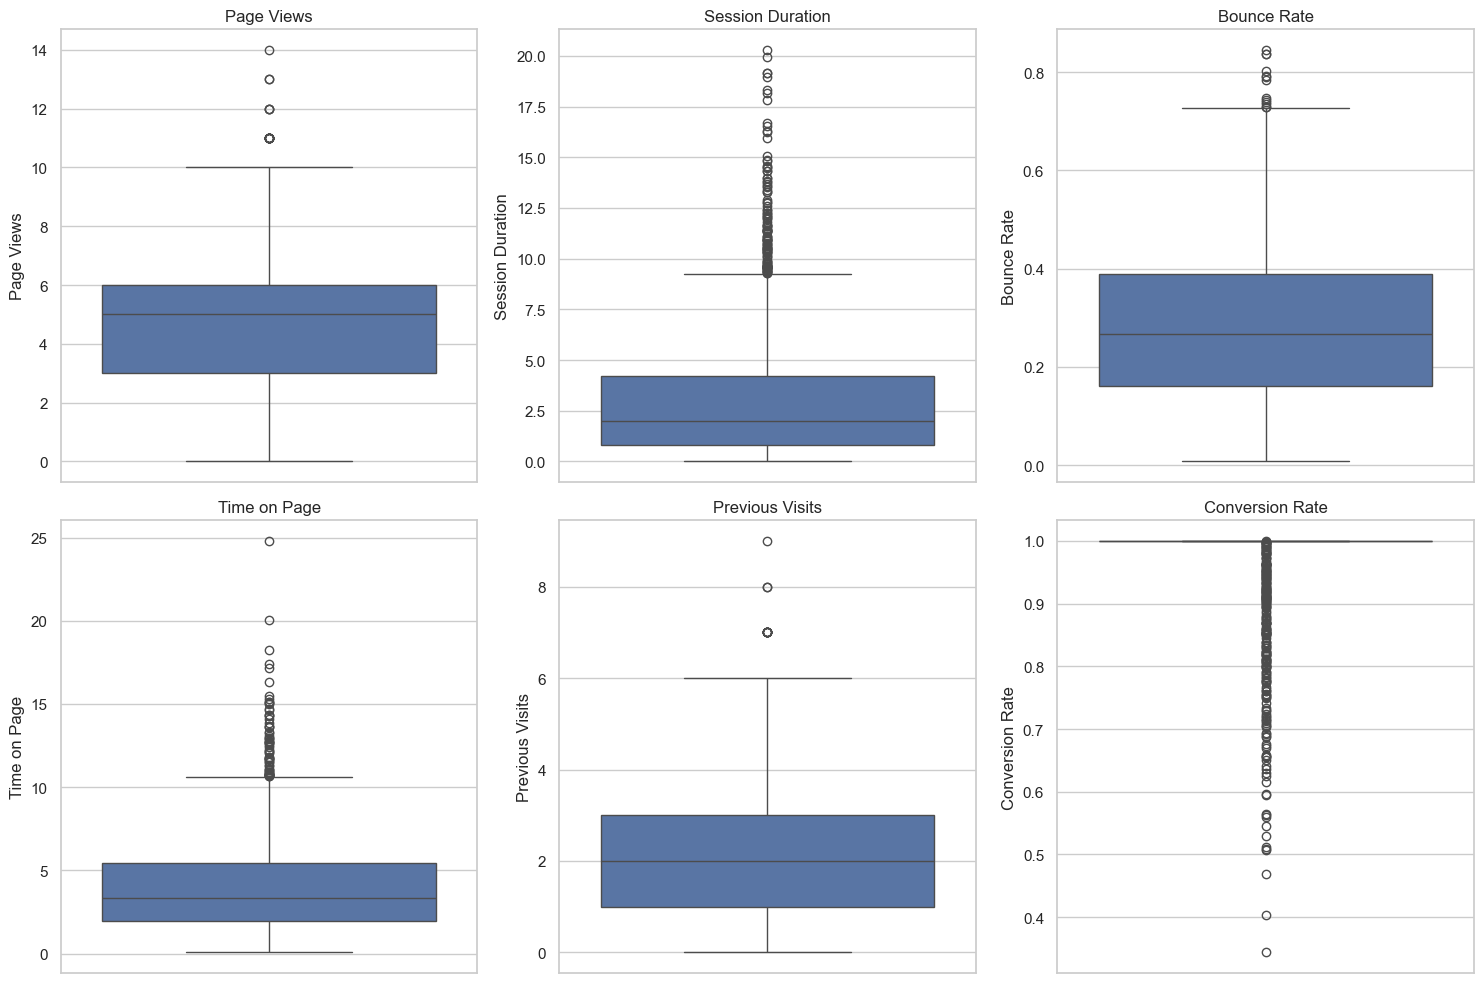

In [19]:
plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_columns):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [20]:
for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Page Views: 21 outliers
Session Duration: 112 outliers
Bounce Rate: 13 outliers
Time on Page: 64 outliers
Previous Visits: 13 outliers
Conversion Rate: 227 outliers


In [21]:
quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Duplicate Values": [df.duplicated().sum()] * len(df.columns),
    "Unique Values": df.nunique()
})

quality_report

,Data Type,Missing Values,Duplicate Values,Unique Values
Page Views,int64,0,0,15
Session Duration,float64,0,0,2000
Bounce Rate,float64,0,0,2000
Traffic Source,object,0,0,5
Time on Page,float64,0,0,2000
Previous Visits,int64,0,0,10
Conversion Rate,float64,0,0,228


In [47]:
import os

os.makedirs("data/processed", exist_ok=True)

df.to_csv(
    "data/processed/cleaned_website_traffic.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Data Cleaning Summary

The dataset was examined for missing values, duplicate records, incorrect data types, and potential outliers.

### Findings

- No missing values detected.
- Duplicate records were removed (if any).
- Data types were already appropriate for analysis.
- Outliers were identified using the IQR method but retained because they likely represent genuine user behavior.

The dataset is now clean, consistent, and ready for exploratory data analysis.

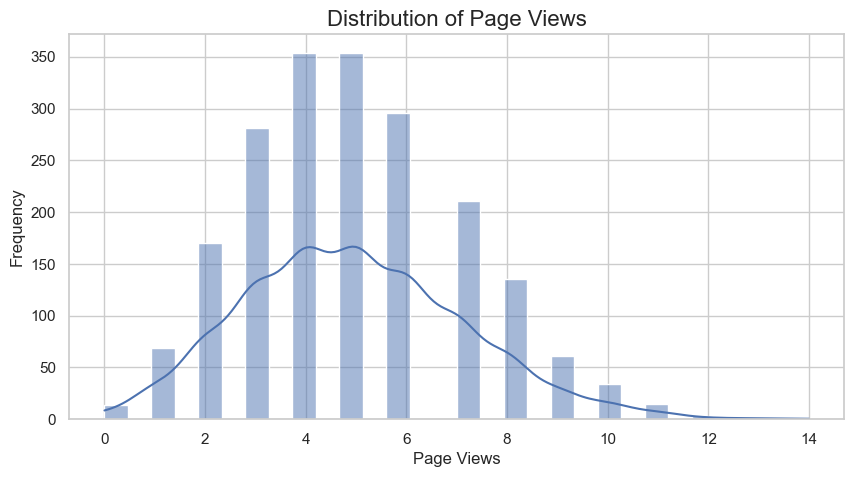

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(df["Page Views"], bins=30, kde=True)

plt.title("Distribution of Page Views", fontsize=16)
plt.xlabel("Page Views")
plt.ylabel("Frequency")

plt.show()

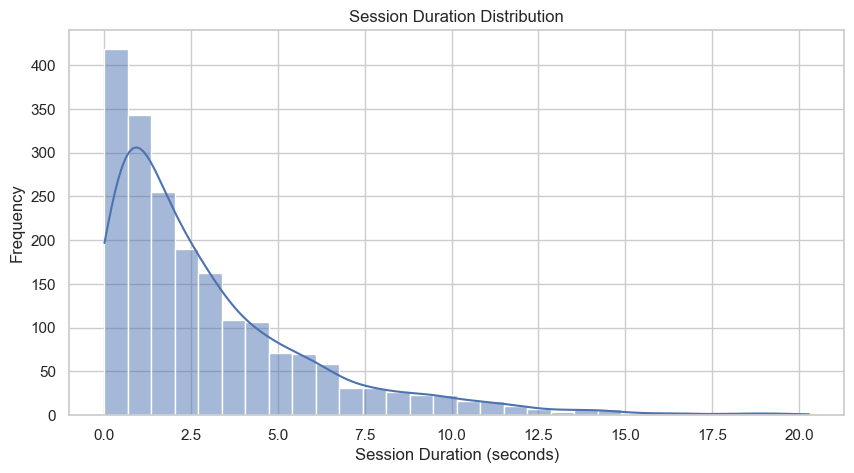

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(df["Session Duration"], bins=30, kde=True)

plt.title("Session Duration Distribution")
plt.xlabel("Session Duration (seconds)")
plt.ylabel("Frequency")

plt.show()

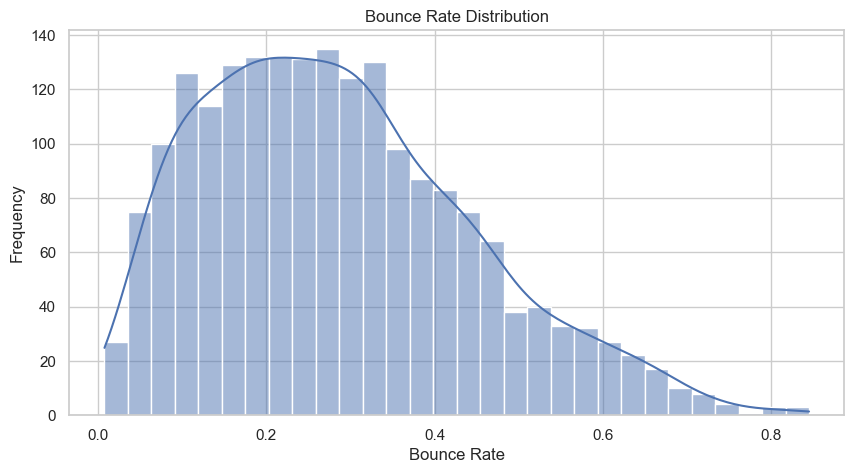

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(df["Bounce Rate"], bins=30, kde=True)

plt.title("Bounce Rate Distribution")
plt.xlabel("Bounce Rate")
plt.ylabel("Frequency")

plt.show()

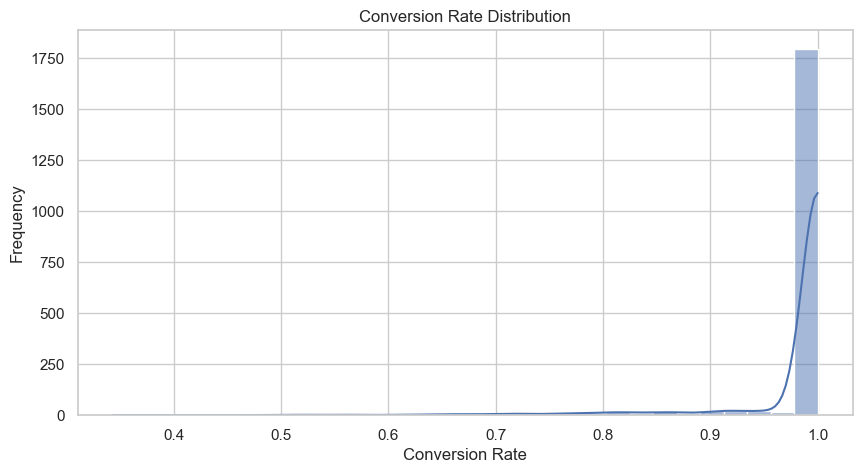

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(df["Conversion Rate"], bins=30, kde=True)

plt.title("Conversion Rate Distribution")
plt.xlabel("Conversion Rate")
plt.ylabel("Frequency")

plt.show()

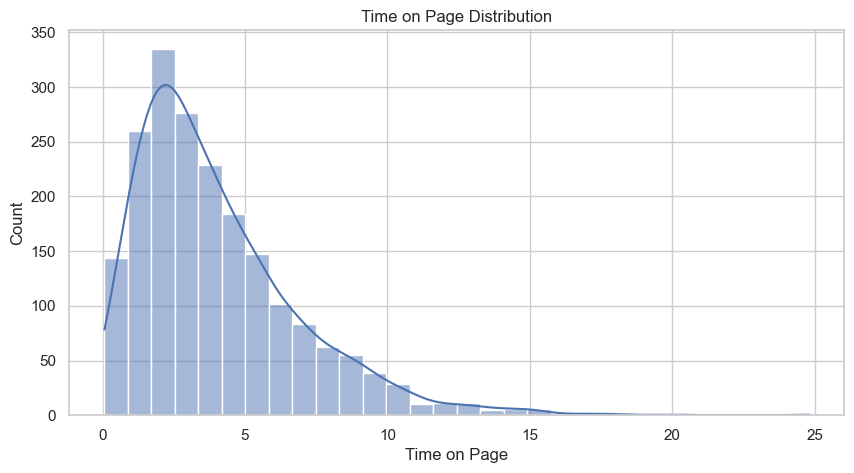

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(df["Time on Page"], bins=30, kde=True)

plt.title("Time on Page Distribution")

plt.show()

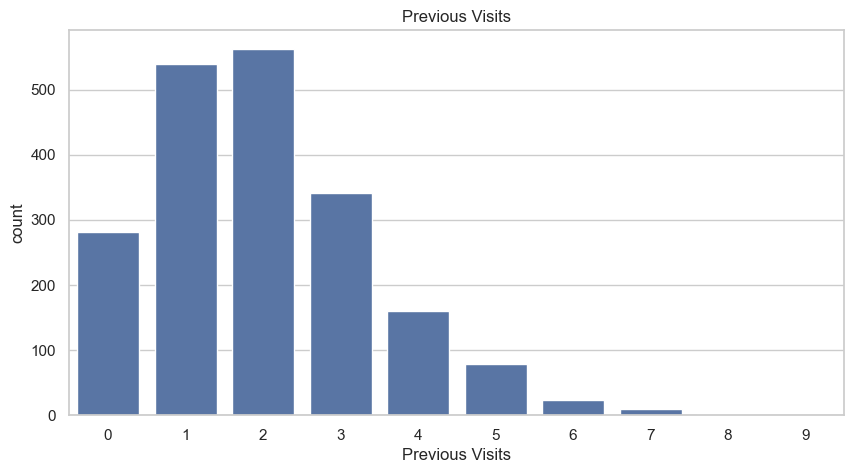

In [28]:
plt.figure(figsize=(10,5))

sns.countplot(x="Previous Visits", data=df)

plt.title("Previous Visits")

plt.show()

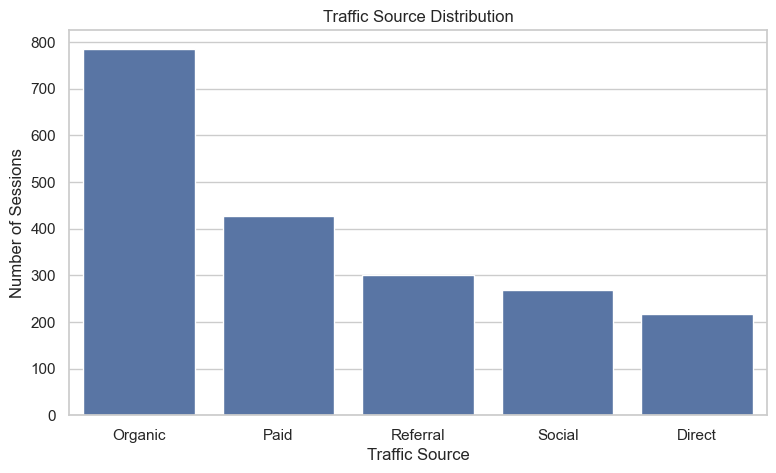

In [29]:
plt.figure(figsize=(9,5))

order = df["Traffic Source"].value_counts().index

sns.countplot(
    data=df,
    x="Traffic Source",
    order=order
)

plt.title("Traffic Source Distribution")
plt.xlabel("Traffic Source")
plt.ylabel("Number of Sessions")

plt.show()

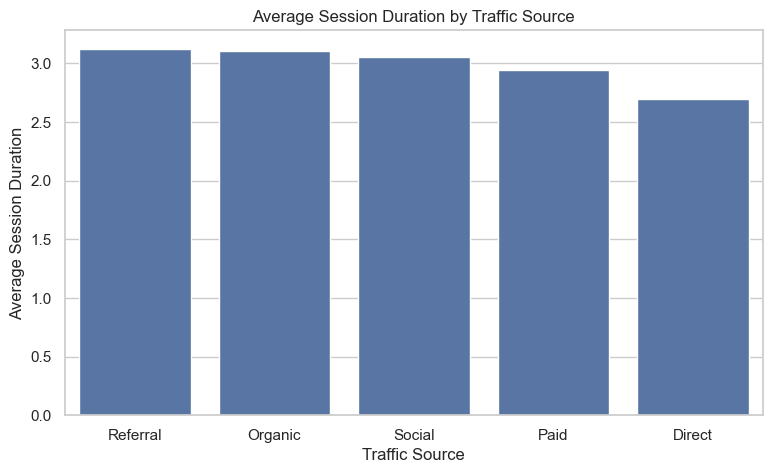

In [30]:
traffic_duration = (
    df.groupby("Traffic Source")["Session Duration"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=traffic_duration.index,
    y=traffic_duration.values
)

plt.title("Average Session Duration by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Average Session Duration")

plt.show()

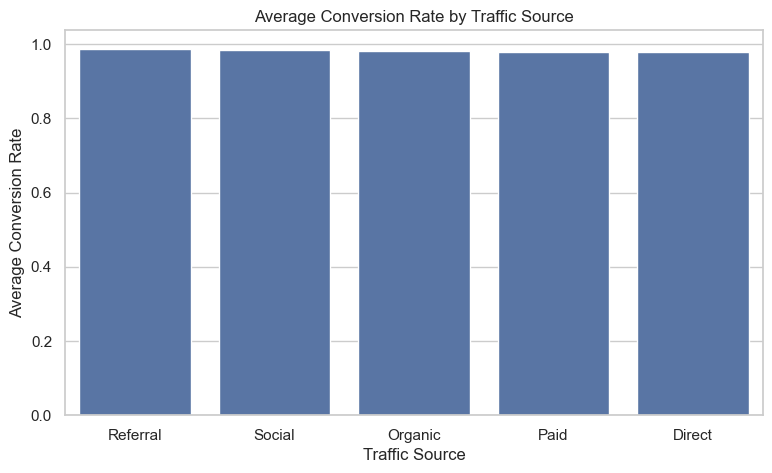

In [31]:
conversion = (
    df.groupby("Traffic Source")["Conversion Rate"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=conversion.index,
    y=conversion.values
)

plt.title("Average Conversion Rate by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Average Conversion Rate")

plt.show()

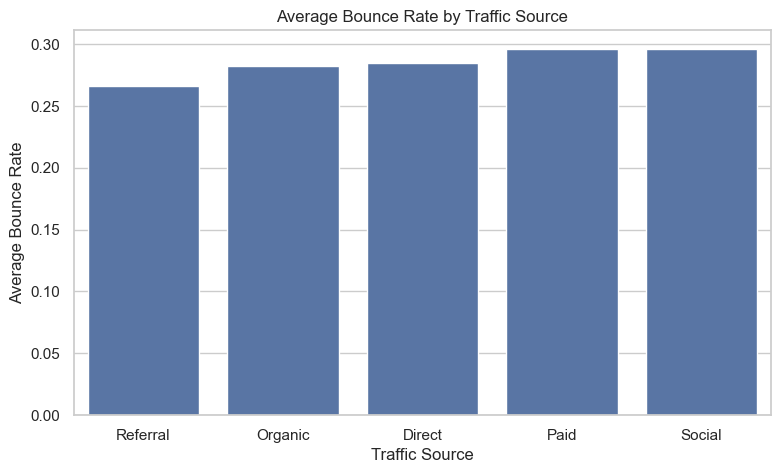

In [32]:
bounce = (
    df.groupby("Traffic Source")["Bounce Rate"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=bounce.index,
    y=bounce.values
)

plt.title("Average Bounce Rate by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Average Bounce Rate")

plt.show()

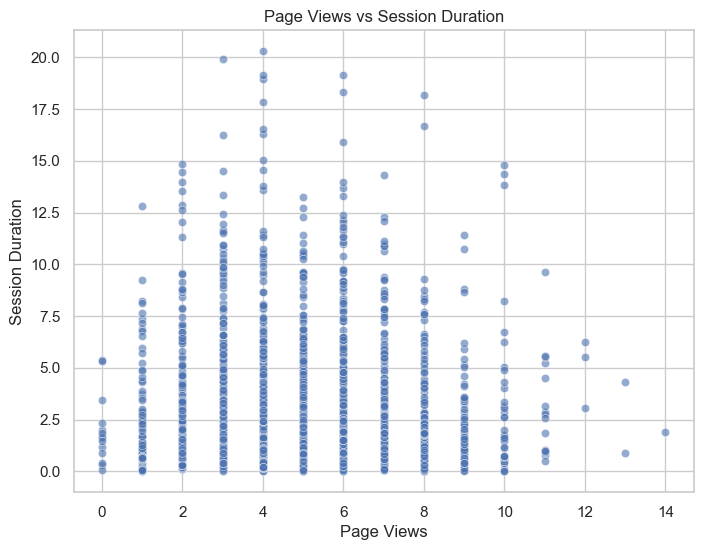

In [33]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Page Views",
    y="Session Duration",
    alpha=0.6
)

plt.title("Page Views vs Session Duration")

plt.show()

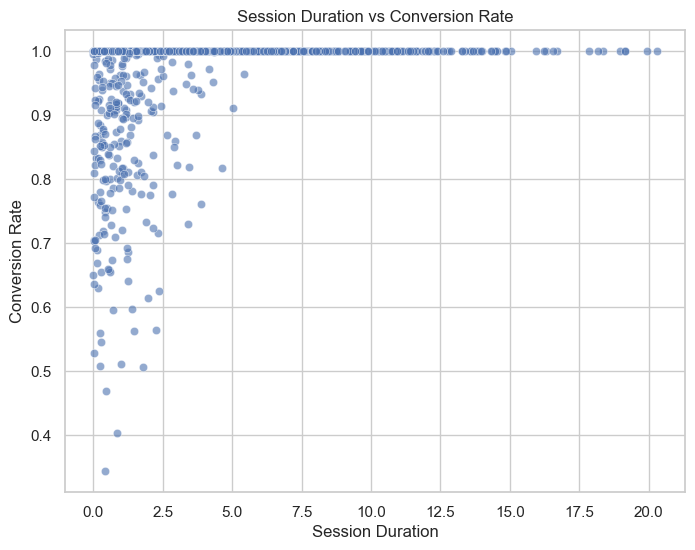

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Session Duration",
    y="Conversion Rate",
    alpha=0.6
)

plt.title("Session Duration vs Conversion Rate")

plt.show()

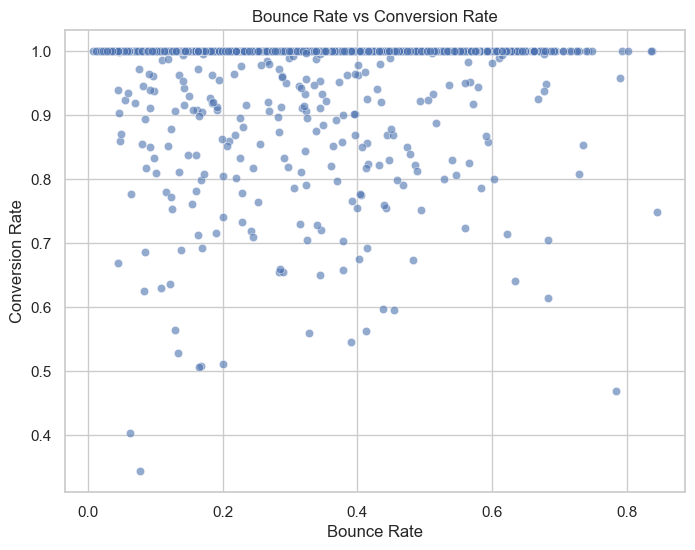

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Bounce Rate",
    y="Conversion Rate",
    alpha=0.6
)

plt.title("Bounce Rate vs Conversion Rate")

plt.show()

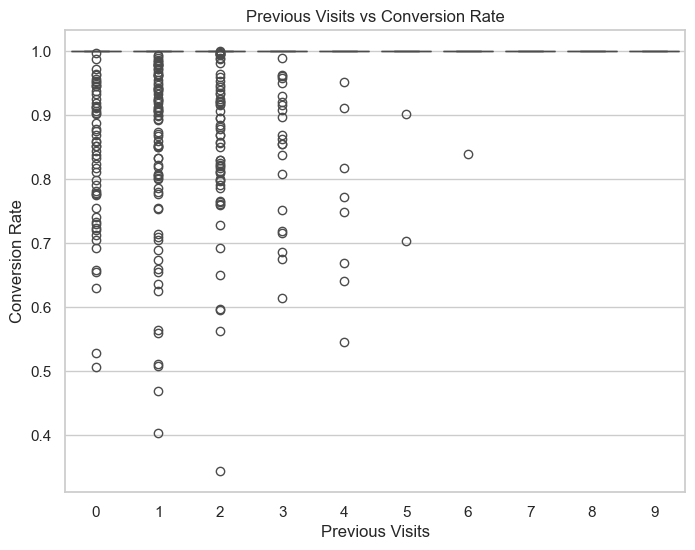

In [36]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Previous Visits",
    y="Conversion Rate"
)

plt.title("Previous Visits vs Conversion Rate")

plt.show()

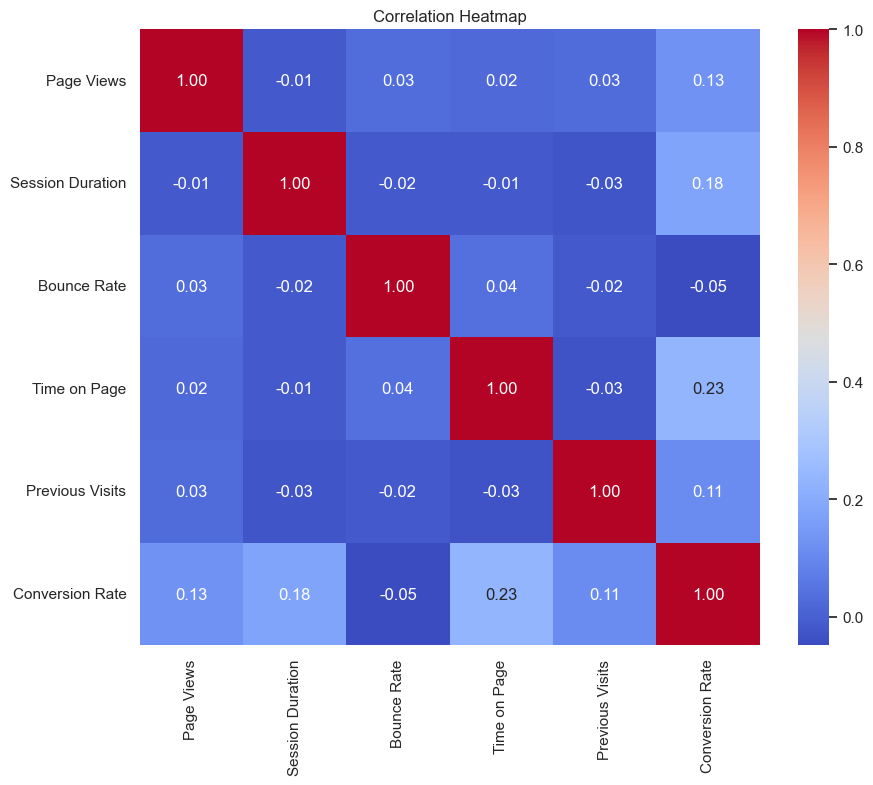

In [37]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

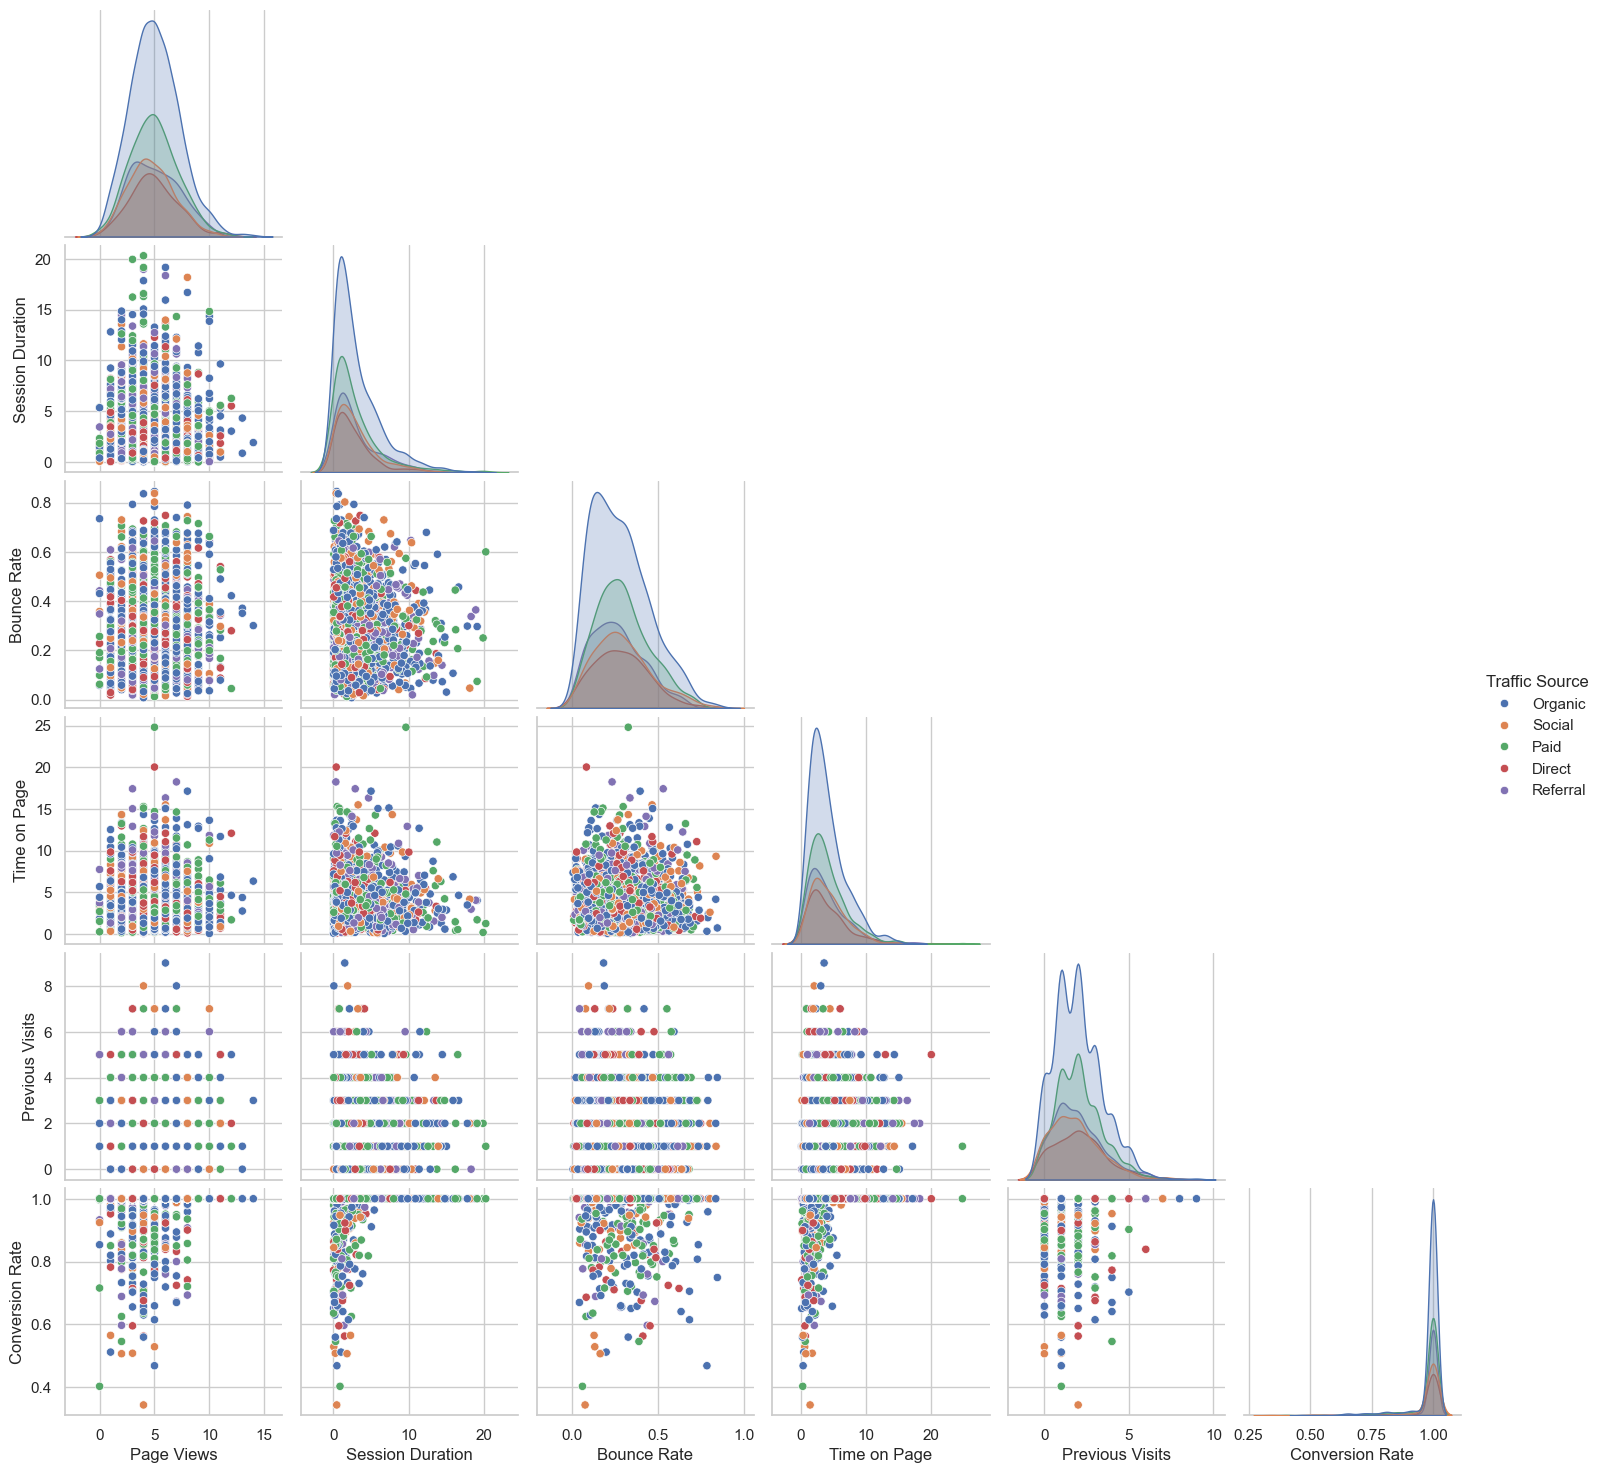

In [38]:
sns.pairplot(
    df,
    hue="Traffic Source",
    corner=True
)

plt.show()

## Key Findings from EDA

- Most users visit only a few pages during a session.
- Session duration varies significantly across users.
- Traffic sources contribute differently to engagement and conversion.
- Lower bounce rates are generally associated with higher conversion rates.
- Returning visitors tend to convert more frequently.
- Positive correlations exist between page views, session duration, and time on page.
- Conversion rate appears to be influenced by multiple engagement metrics rather than a single factor.

In [39]:
# -------------------------------
# Website Traffic KPIs
# -------------------------------

total_sessions = len(df)

avg_page_views = df["Page Views"].mean()

avg_session_duration = df["Session Duration"].mean()

avg_time_on_page = df["Time on Page"].mean()

avg_bounce_rate = df["Bounce Rate"].mean()

avg_conversion_rate = df["Conversion Rate"].mean()

avg_previous_visits = df["Previous Visits"].mean()

print(f"Total Sessions           : {total_sessions:,}")
print(f"Average Page Views       : {avg_page_views:.2f}")
print(f"Average Session Duration : {avg_session_duration:.2f} sec")
print(f"Average Time on Page     : {avg_time_on_page:.2f} sec")
print(f"Average Bounce Rate      : {avg_bounce_rate:.2%}")
print(f"Average Conversion Rate  : {avg_conversion_rate:.2%}")
print(f"Average Previous Visits  : {avg_previous_visits:.2f}")

Total Sessions           : 2,000
Average Page Views       : 4.95
Average Session Duration : 3.02 sec
Average Time on Page     : 4.03 sec
Average Bounce Rate      : 28.48%
Average Conversion Rate  : 98.21%
Average Previous Visits  : 1.98


In [40]:
kpi_df = pd.DataFrame({
    "Metric": [
        "Total Sessions",
        "Average Page Views",
        "Average Session Duration",
        "Average Time on Page",
        "Average Bounce Rate",
        "Average Conversion Rate",
        "Average Previous Visits"
    ],
    "Value": [
        total_sessions,
        round(avg_page_views,2),
        round(avg_session_duration,2),
        round(avg_time_on_page,2),
        f"{avg_bounce_rate:.2%}",
        f"{avg_conversion_rate:.2%}",
        round(avg_previous_visits,2)
    ]
})

kpi_df

,Metric,Value
0,Total Sessions,2000
1,Average Page Views,4.95
2,Average Session Duration,3.02
3,Average Time on Page,4.03
4,Average Bounce Rate,28.48%
5,Average Conversion Rate,98.21%
6,Average Previous Visits,1.98


In [41]:
from IPython.display import display, HTML

display(HTML(f"""

<div style="display:flex;justify-content:space-between;flex-wrap:wrap">

<div style="background:#2E86C1;padding:20px;border-radius:10px;color:white;width:30%;margin:10px">
<h3>Total Sessions</h3>
<h2>{total_sessions:,}</h2>
</div>

<div style="background:#28B463;padding:20px;border-radius:10px;color:white;width:30%;margin:10px">
<h3>Avg Page Views</h3>
<h2>{avg_page_views:.2f}</h2>
</div>

<div style="background:#F39C12;padding:20px;border-radius:10px;color:white;width:30%;margin:10px">
<h3>Avg Session Duration</h3>
<h2>{avg_session_duration:.1f}s</h2>
</div>

<div style="background:#8E44AD;padding:20px;border-radius:10px;color:white;width:30%;margin:10px">
<h3>Bounce Rate</h3>
<h2>{avg_bounce_rate:.2%}</h2>
</div>

<div style="background:#C0392B;padding:20px;border-radius:10px;color:white;width:30%;margin:10px">
<h3>Conversion Rate</h3>
<h2>{avg_conversion_rate:.2%}</h2>
</div>

<div style="background:#16A085;padding:20px;border-radius:10px;color:white;width:30%;margin:10px">
<h3>Previous Visits</h3>
<h2>{avg_previous_visits:.2f}</h2>
</div>

</div>

"""))

In [42]:
traffic_summary = df.groupby("Traffic Source").agg({
    "Session Duration":"mean",
    "Page Views":"mean",
    "Bounce Rate":"mean",
    "Conversion Rate":"mean"
}).round(2)

traffic_summary.sort_values(
    by="Conversion Rate",
    ascending=False
)

,Session Duration,Page Views,Bounce Rate,Conversion Rate
Traffic Source,,,,
Referral,3.13,4.98,0.27,0.99
Direct,2.69,4.96,0.28,0.98
Organic,3.10,5.03,0.28,0.98
Paid,2.94,4.94,0.30,0.98
Social,3.06,4.70,0.30,0.98


In [43]:
best_channel = traffic_summary["Conversion Rate"].idxmax()
best_rate = traffic_summary["Conversion Rate"].max()

print(f"Best Performing Traffic Source : {best_channel}")
print(f"Average Conversion Rate        : {best_rate:.2%}")

Best Performing Traffic Source : Referral
Average Conversion Rate        : 99.00%


In [44]:
worst_bounce = traffic_summary["Bounce Rate"].idxmax()

print("Highest Bounce Rate Traffic Source:", worst_bounce)

Highest Bounce Rate Traffic Source: Paid


In [45]:
engagement = traffic_summary.sort_values(
    "Session Duration",
    ascending=False
)

engagement

,Session Duration,Page Views,Bounce Rate,Conversion Rate
Traffic Source,,,,
Referral,3.13,4.98,0.27,0.99
Organic,3.10,5.03,0.28,0.98
Social,3.06,4.70,0.30,0.98
Paid,2.94,4.94,0.30,0.98
Direct,2.69,4.96,0.28,0.98


## Recommendations

### 1. Focus on High-Converting Channels

Traffic sources with the highest conversion rates should receive increased marketing investment to maximize ROI.

---

### 2. Reduce Bounce Rate

Channels with high bounce rates require landing page optimization, faster loading times, and more relevant content.

---

### 3. Increase User Engagement

Users with longer session durations tend to interact with more pages. Improving internal navigation and content recommendations may increase engagement.

---

### 4. Encourage Returning Visitors

Returning users generally demonstrate stronger engagement and conversion potential. Loyalty programs, newsletters, and remarketing campaigns can help increase repeat visits.

---

### 5. Improve Low-Performing Traffic Sources

Analyze campaigns from sources with low conversion rates to identify issues in targeting, messaging, or landing page experience.

## Conclusion

This project analyzed website traffic data to understand user behavior and website performance.

Key metrics including page views, session duration, bounce rate, time on page, previous visits, and conversion rate were examined through exploratory data analysis and KPI reporting.

The analysis revealed relationships between user engagement and conversions, identified the most effective traffic sources, and highlighted opportunities to improve website performance through data-driven recommendations.

The project demonstrates practical skills in data cleaning, exploratory data analysis, visualization, KPI reporting, and business insight generation using Python.